## Model median cost/watt as function of three feature: time (days), size_group, state

### Notes: just had another thought: do my aggregates have any zeros in them when try to fit?  if so, what does that do?

I don't think there are zeros or NaN because sklearn would complain about nans and if there's no data for a period, there's just no value for the aggregate (I'm not marching along looking at every period - maybe I should be?).



###  transform the data

Compute the median of cost/watt, grouped by time, size_group and state.

It might be useful to leave state out to begin.  The best time window grouping for the time only model was week, so begin with that.


In [1]:
import datetime

In [2]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('figure', figsize=(10, 8))
np.set_printoptions(precision=4, suppress=False)
# please show all columns
pd.set_option("display.max_columns", 60)
import seaborn as sns
sns.set()

In [3]:
# Import sklearn stuff

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

In [4]:
# load up
dfMod = pd.read_csv('../local/data/LBNL_openpv_tts_data/ModelData.csv',
                    encoding='iso-8859-1', # avoids windows encoding issue
                    index_col='row_id',
                    parse_dates=['install_date'])

In [5]:
dfMod.head()

,num_days,size_kw,state,cost_per_watt,install_date,scaleSize
row_id,,,,,,
1,0,2.2824,CA,10.734315,1998-01-09,0
2,21,1.8504,CA,11.108701,1998-01-30,0
4,26,2.3076,CA,8.667013,1998-02-04,0
6,84,2.3316,CA,13.270286,1998-04-03,0
7,111,0.9300,CA,14.654839,1998-04-30,0


In [6]:
# capture the installation month for each row
month = dfMod.install_date.apply(lambda x: x.to_period('M'))

# save in a new column
dfMod = dfMod.assign(install_month=month)

In [7]:
week = dfMod.install_date.apply(lambda x: x.to_period('W'))

In [8]:
week.head()

row_id
1   1998-01-05/1998-01-11
2   1998-01-26/1998-02-01
4   1998-02-02/1998-02-08
6   1998-03-30/1998-04-05
7   1998-04-27/1998-05-03
Name: install_date, dtype: object

In [9]:
dfMod = dfMod.assign(install_week=week)

In [10]:
dfMod.columns

Index(['num_days', 'size_kw', 'state', 'cost_per_watt', 'install_date',
       'scaleSize', 'install_month', 'install_week'],
      dtype='object')

#### I want a column for size_group

It's there already.  No need to add it.

In [11]:
# scaleSize = dfMod.size_kw/2.5
# scaleSize = scaleSize.astype(np.int)
# dfMod = dfMod.assign(scaleSize=scaleSize)

### It's a good idea to leave these calculated columns in the data and save it out so I don't have to keep computing them.

In [12]:
dfMod[['scaleSize']].describe()

,scaleSize
count,364212.000000
mean,1.928089
std,1.327916
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,9.000000


####   We don't need to keep day0 around because it's the first element of the column.

In [14]:
# reorder the columns
# keep  'install_date', 'num_days', 'install_week', 'install_month', 'size_kw', 'state', 'cost_per_watt'
dfMod = dfMod[['install_date', 'num_days', 'install_week', 'install_month', 'size_kw', 'scaleSize', 'state', 'cost_per_watt']]

In [15]:
dfMod.head()

,install_date,num_days,install_week,install_month,size_kw,scaleSize,state,cost_per_watt
row_id,,,,,,,,
1,1998-01-09,0,1998-01-05/1998-01-11,1998-01,2.2824,0,CA,10.734315
2,1998-01-30,21,1998-01-26/1998-02-01,1998-01,1.8504,0,CA,11.108701
4,1998-02-04,26,1998-02-02/1998-02-08,1998-02,2.3076,0,CA,8.667013
6,1998-04-03,84,1998-03-30/1998-04-05,1998-04,2.3316,0,CA,13.270286
7,1998-04-30,111,1998-04-27/1998-05-03,1998-04,0.9300,0,CA,14.654839


In [16]:
dfMod.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 364212 entries, 1 to 1094908
Data columns (total 8 columns):
install_date     364212 non-null datetime64[ns]
num_days         364212 non-null int64
install_week     364212 non-null object
install_month    364212 non-null object
size_kw          364212 non-null float64
scaleSize        364212 non-null int32
state            364212 non-null object
cost_per_watt    364212 non-null float64
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(3)
memory usage: 23.6+ MB


### Group by day and scaleSize

In [20]:
by_date_size = dfMod.groupby(['install_date', 'scaleSize'])
med_date_size = by_date_size.cost_per_watt.median()
mean_date_size = by_date_size.cost_per_watt.mean()
print(med_date_size.head())
print()
print(mean_date_size.head())
print

### unstack it see what it looks like
med_by_date_size = med_date_size.unstack('scaleSize'); med_by_date_size.head()

install_date  scaleSize
1998-01-09    0            10.734315
1998-01-30    0            11.108701
1998-02-04    0             8.667013
1998-04-03    0            13.270286
1998-04-30    0            14.654839
Name: cost_per_watt, dtype: float64

install_date  scaleSize
1998-01-09    0            10.734315
1998-01-30    0            11.108701
1998-02-04    0             8.667013
1998-04-03    0            13.270286
1998-04-30    0            14.654839
Name: cost_per_watt, dtype: float64


scaleSize,0,1,2,3,4,5,6,7,8,9
install_date,,,,,,,,,,
1998-01-09,10.734315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-01-30,11.108701,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-02-04,8.667013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-04-03,13.270286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-04-30,14.654839,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Days is too short a window...

Doesn't reject enough noise because of small samples...

In [21]:
med_by_date_size.columns

Int64Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype='int64', name='scaleSize')

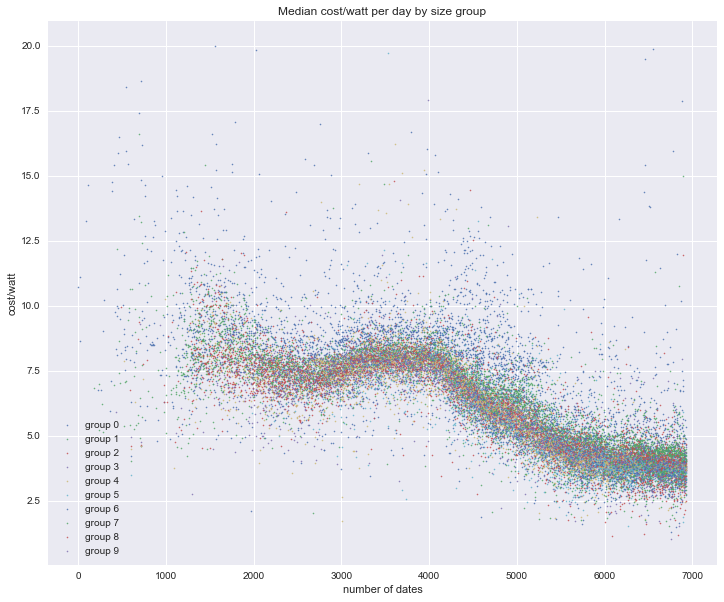

In [22]:
fig, ax = plt.subplots(figsize=(12, 10))
sTitle = 'Median cost/watt per day by size group'

ax.set_title(sTitle)
for i in range(0, 10):
    ax.scatter((med_by_date_size.index - med_by_date_size.index[0]).days, med_by_date_size.iloc[:,i],
               marker='.', s=6, alpha=0.8, label='group {}'.format(str(i)))

ax.set_ylabel('cost/watt')
ax.set_xlabel('number of dates')
ax.legend()

plt.show();

### now by week

In [25]:
by_week_size = dfMod.groupby(['install_week', 'scaleSize'])
med_by_week_size = by_week_size.cost_per_watt.median()
mean_by_week_size = by_week_size.cost_per_watt.mean()
print(med_by_week_size.head())
print()
print(mean_by_week_size.head())
print

### unstack it see what it looks like; yes, that's what we need for plotting
### orginal for is almost right for sklearn...
med_by_week_size = med_by_week_size.unstack('scaleSize'); med_by_week_size.head()

install_week           scaleSize
1998-01-05/1998-01-11  0            10.734315
1998-01-26/1998-02-01  0            11.108701
1998-02-02/1998-02-08  0             8.667013
1998-03-30/1998-04-05  0            13.270286
1998-04-27/1998-05-03  0            14.654839
Name: cost_per_watt, dtype: float64

install_week           scaleSize
1998-01-05/1998-01-11  0            10.734315
1998-01-26/1998-02-01  0            11.108701
1998-02-02/1998-02-08  0             8.667013
1998-03-30/1998-04-05  0            13.270286
1998-04-27/1998-05-03  0            14.654839
Name: cost_per_watt, dtype: float64


scaleSize,0,1,2,3,4,5,6,7,8,9
install_week,,,,,,,,,,
1998-01-05/1998-01-11,10.734315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-01-26/1998-02-01,11.108701,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-02-02/1998-02-08,8.667013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-03-30/1998-04-05,13.270286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-04-27/1998-05-03,14.654839,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


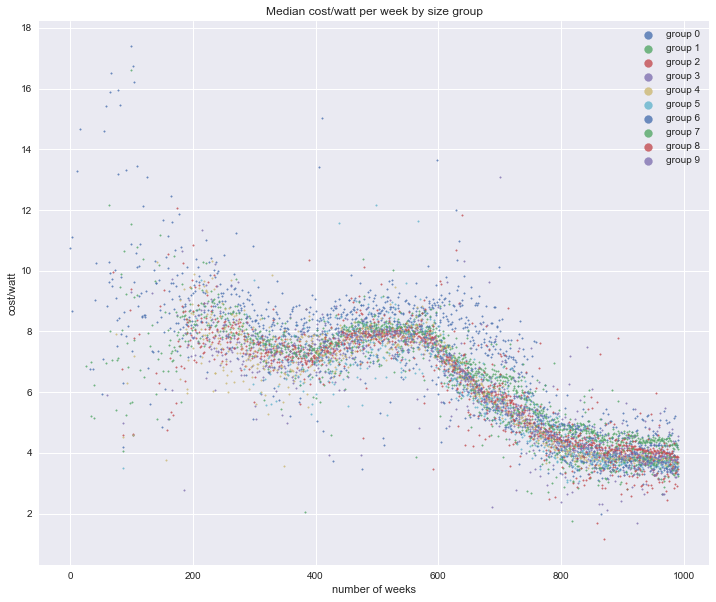

In [26]:
fig, ax = plt.subplots(figsize=(12, 10))
sTitle = 'Median cost/watt per week by size group'

ax.set_title(sTitle)
for i in range(0, 10):
    ax.scatter((med_by_week_size.index - med_by_week_size.index[0]), med_by_week_size.iloc[:,i],
               marker='.', s=10, alpha=0.8, label='group {}'.format(str(i)))

ax.set_ylabel('cost/watt')
ax.set_xlabel('number of weeks')
ax.legend(markerscale=5)

plt.show();

### What the hell, let's just model it and see what happens...

In [28]:
#### the comment below is not true any more. 
### maybe I need to restack it or use the thing I had before I unstacked for plotting.
### WRONG!  the Xs are in the index; the ys are vals.
med_by_week_size.head()

scaleSize,0,1,2,3,4,5,6,7,8,9
install_week,,,,,,,,,,
1998-01-05/1998-01-11,10.734315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-01-26/1998-02-01,11.108701,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-02-02/1998-02-08,8.667013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-03-30/1998-04-05,13.270286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-04-27/1998-05-03,14.654839,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
### okay, I smashed it above when I did the unstack
### this gets me back to before the plotting
by_week_size = dfMod.groupby(['install_week', 'scaleSize'])
med_by_week_size = by_week_size.cost_per_watt.median()
mean_by_week_size = by_week_size.cost_per_watt.mean()
print(med_by_week_size.head())
print()
print(mean_by_week_size.head())
print

### orginal for is almost right for sklearn...
med_by_week_size.head()

install_week           scaleSize
1998-01-05/1998-01-11  0            10.734315
1998-01-26/1998-02-01  0            11.108701
1998-02-02/1998-02-08  0             8.667013
1998-03-30/1998-04-05  0            13.270286
1998-04-27/1998-05-03  0            14.654839
Name: cost_per_watt, dtype: float64

install_week           scaleSize
1998-01-05/1998-01-11  0            10.734315
1998-01-26/1998-02-01  0            11.108701
1998-02-02/1998-02-08  0             8.667013
1998-03-30/1998-04-05  0            13.270286
1998-04-27/1998-05-03  0            14.654839
Name: cost_per_watt, dtype: float64


install_week           scaleSize
1998-01-05/1998-01-11  0            10.734315
1998-01-26/1998-02-01  0            11.108701
1998-02-02/1998-02-08  0             8.667013
1998-03-30/1998-04-05  0            13.270286
1998-04-27/1998-05-03  0            14.654839
Name: cost_per_watt, dtype: float64

In [42]:
### shove over so I can grab the pieces as columns
df_med_week_size = med_by_week_size.reset_index(); df_med_week_size.head()

,install_week,scaleSize,cost_per_watt
0,1998-01-05/1998-01-11,0,10.734315
1,1998-01-26/1998-02-01,0,11.108701
2,1998-02-02/1998-02-08,0,8.667013
3,1998-03-30/1998-04-05,0,13.270286
4,1998-04-27/1998-05-03,0,14.654839


In [43]:
### yes, it's tall and skinny
df_med_week_size.shape

(6598, 3)

In [44]:
### yeah, these numbers are different than if I just bin the data.
df_med_week_size.describe()

,scaleSize,cost_per_watt
count,6598.000000,6598.000000
mean,3.652622,6.252432
std,2.680043,1.894916
min,0.000000,1.152500
25%,1.000000,4.430274
50%,3.000000,6.548005
75%,6.000000,7.770283
max,9.000000,17.403333


### go from install_week to number of weeks

week0 = df_med_week_size['install_week'][0]; week0

num_weeks = (df_med_week_size['install_week'] - week0 )
num_weeks = num_weeks.astype(np.float)
num_weeks[:5]

In [46]:
df_med_week_size = df_med_week_size.assign(install_week=num_weeks)
df_med_week_size.head()

,install_week,scaleSize,cost_per_watt
0,0.0,0,10.734315
1,3.0,0,11.108701
2,4.0,0,8.667013
3,12.0,0,13.270286
4,16.0,0,14.654839


### Almost there 

In [48]:
print(df_med_week_size.columns)

Index(['install_week', 'scaleSize', 'cost_per_watt'], dtype='object')


In [49]:
the_sizes = df_med_week_size.scaleSize.astype(np.float)
df_med_week_size = df_med_week_size.assign(scaleSize=the_sizes)
df_med_week_size.head()

,install_week,scaleSize,cost_per_watt
0,0.0,0.0,10.734315
1,3.0,0.0,11.108701
2,4.0,0.0,8.667013
3,12.0,0.0,13.270286
4,16.0,0.0,14.654839


### Okay, model away

In [50]:
X = df_med_week_size[['install_week', 'scaleSize']].values
y = df_med_week_size[['cost_per_watt']].values
X.shape, y.shape

((6598, 2), (6598, 1))

In [53]:
# Setup the pipeline steps
steps = [('scaler', StandardScaler()),
         ('poly', PolynomialFeatures()),
         ('LR', LinearRegression())]

# Create the pipeline: pipeline 
pipeline = Pipeline(steps)

In [54]:
# want to plot both R2 and RMSE
def RMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Create the hyperparameter grid, just poly degree
poly_space = np.arange(1, 15)
param_grid = {'poly__degree': poly_space}

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=21)

# build the scoring map
scoring = {'Rsquared': 'r2',
           'RMSE': make_scorer(RMSE, greater_is_better=False) }

# Create the GridSearchCV object: gs_cv
gs_cv = GridSearchCV(pipeline, param_grid, cv=3, scoring=scoring, 
                     return_train_score=True, refit='Rsquared')

# Fit to the training set
gs_cv.fit(X_train, y_train)

# Compute and print the metrics
theR2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("test R squared: {}".format(theR2))

# uncomment to see results ds
# gs_cv.cv_results_

Best parameters: {'poly__degree': 9}
test R squared: 0.8334481891457562


Best parameters: {'poly__degree': 9}
Best R squared: 0.8334481891457562


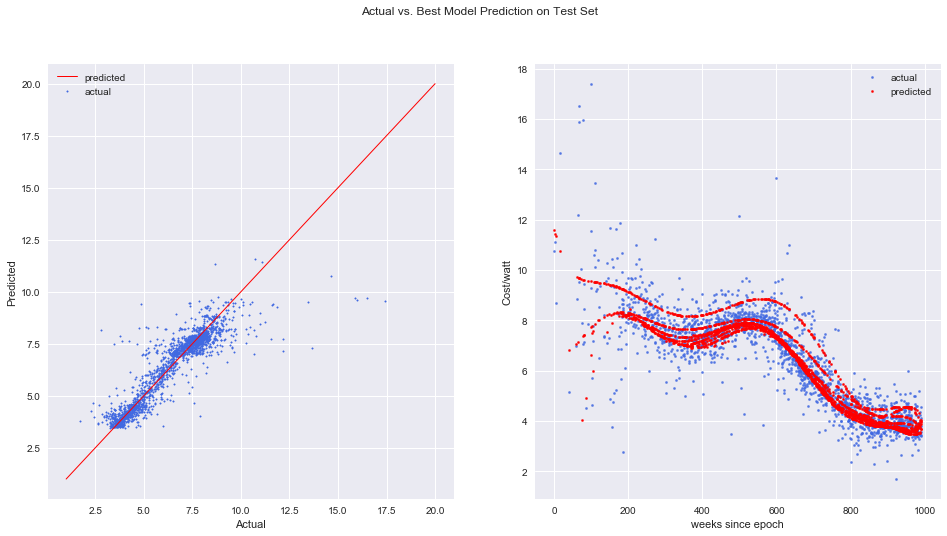

In [68]:
# Show R2
theR2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("Best R squared: {}".format(theR2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Actual vs. Best Model Prediction on Test Set')

ax1.scatter(y_test, gs_cv.predict(X_test), marker='.', s=10, color='royalblue', alpha=1, label='actual')
ax1.plot(np.array([1,20]), np.array([1,20]), linewidth=1, color='red', label='predicted')
ax1.set_ylabel('Predicted')
ax1.set_xlabel('Actual')
ax1.legend()

ax2.scatter(X_test[:, 0], y_test, marker='.', color='royalblue', s=20, alpha=0.9, label='actual')
ax2.scatter(X_test[:, 0], gs_cv.predict(X_test), marker='.', color='red', s=20, alpha=1, label='predicted')
ax2.set_ylabel('Cost/watt')
ax2.set_xlabel('weeks since epoch')
ax2.legend()

plt.show();

### Extrapolate with best model

#### Build an X with scaleSize 5

In [69]:
x1 = np.linspace(0.0, 1250.0, int(1250/13)); x1.shape
x2 = np.zeros(96); x2[:] = 5.0
print(x1.shape, x2.shape)

(96,) (96,)


In [70]:
thing = np.stack([x1, x2], axis=-1); thing.shape

(96, 2)

In [71]:
X_future = thing

In [72]:
X_future[:, 0].reshape(-1, 1).shape

(96, 1)

In [73]:
gs_cv.predict(X_future).shape

(96, 1)

In [74]:
X_f5 = X_future
X_f1 = X_future.copy()
X_f1[:, 1] = 1.0

In [75]:
X_f9 = X_future.copy()
X_f9[:, 1] = 9.0
X_f9[:5, :]

array([[ 0.    ,  9.    ],
       [13.1579,  9.    ],
       [26.3158,  9.    ],
       [39.4737,  9.    ],
       [52.6316,  9.    ]])

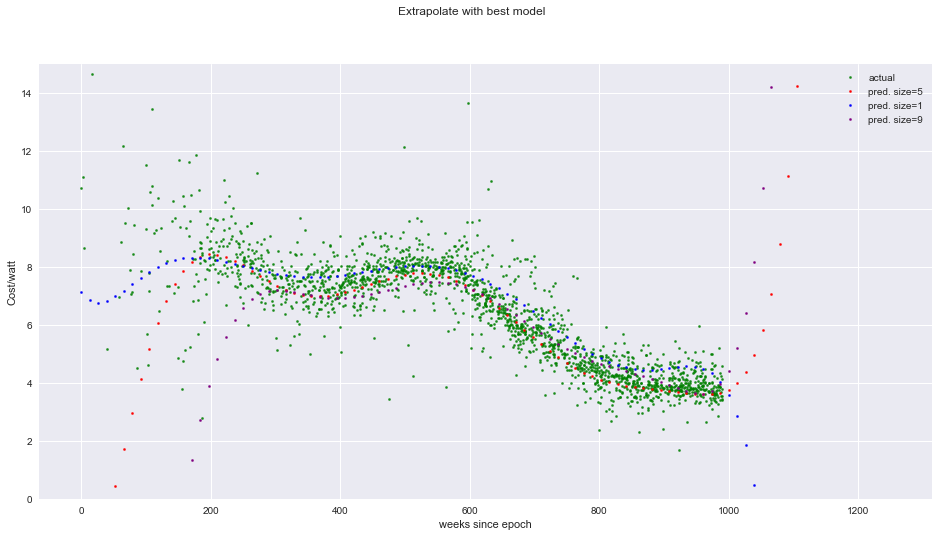

In [76]:
fig, ax = plt.subplots(figsize=(16, 8))
fig.suptitle('Extrapolate with best model')


ax.scatter(X_test[:,0], y_test, marker='.', color='green', s=20, alpha=0.9, label='actual')
ax.scatter(X_f5[:, 0].reshape(-1, 1), gs_cv.predict(X_f5), marker='.', color='red', s=20, alpha=1, label='pred. size=5')
ax.scatter(X_f1[:, 0].reshape(-1, 1), gs_cv.predict(X_f1), marker='.', color='blue', s=20, alpha=1, label='pred. size=1')
ax.scatter(X_f9[:, 0].reshape(-1, 1), gs_cv.predict(X_f9), marker='.', color='purple', s=20, alpha=1, label='pred. size=9')
ax.set_ylabel('Cost/watt')
ax.set_xlabel('weeks since epoch')
ax.set_ylim(0,15)
ax.legend();

In [77]:
gs_cv.cv_results_

{'mean_fit_time': array([0.002 , 0.0017, 0.0023, 0.0023, 0.0033, 0.0047, 0.0043, 0.007 ,
        0.0084, 0.01  , 0.0147, 0.013 , 0.0157, 0.0224]),
 'std_fit_time': array([8.1887e-04, 4.7345e-04, 4.7283e-04, 4.7460e-04, 4.7255e-04,
        1.2491e-03, 4.7418e-04, 2.6190e-06, 1.2505e-03, 3.8934e-07,
        3.1000e-03, 7.8674e-07, 4.7176e-04, 1.2505e-03]),
 'mean_score_time': array([0.001 , 0.001 , 0.001 , 0.0013, 0.0023, 0.0027, 0.003 , 0.0027,
        0.004 , 0.0043, 0.0067, 0.0074, 0.0084, 0.0104]),
 'std_score_time': array([6.2577e-07, 4.0523e-07, 2.2478e-07, 4.7469e-04, 4.7266e-04,
        9.5044e-04, 8.1936e-04, 4.7171e-04, 8.1877e-04, 4.7278e-04,
        2.0594e-03, 4.7036e-04, 4.7058e-04, 9.4465e-04]),
 'param_poly__degree': masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
              mask=[False, False, False, False, False, False, False, False,
                    False, False, False, False, False, False],
        fill_value='?',
             dtype=object),
 

### Okay, these predictions suck...  It seems way overfitted but the crossval isn't helping

This is without even including the state.  Maybe it's trying to use time and size to model variance caused by state (i.e. misuse).  The state accounts for maybe \$1 and best test RMSE is about \$0.77.  So, hmmm...

Another thing: maybe I don't want to poly expand size; it's a simple relation - slight negative correlation.  Would that help?

The good news: these are very fast to fit; might make sense to drive a search outside of grid_search_cv...

Here's another idea (just in case I run out): what about using size to weight the price instead of using as parameter.  I wonder what that would do (have to learn the technique).

While I'm brainstorming, the vendor could matter.

## 3rd degree model looks okay and predictions look okay...

Also, I'm wondering if I should be using median size for the groups instead of an integer.  I'm not sure how to get that - I guess I could compute in another groupby just the way I compute the median cost/watt.  Then build that into the X.


In [66]:
def trainVsTestResults(results, ylim=1.4): 
    ''' Plot test/train results for R^2 and RMSE'''    

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    sTitle = 'mean cross-validation train/test RMSE and R^2 vs poly degree'
    fig.suptitle(sTitle)
          
    mean_train_RMSE = results['mean_train_RMSE']
    mean_test_RMSE = results['mean_test_RMSE']
    n = len(mean_train_RMSE)
        
    ax1.plot(np.arange(1, n + 1), np.abs(mean_train_RMSE), marker='d', ms=15, alpha=0.5, color='green', label='train');
    ax1.plot(np.arange(1, n + 1), np.abs(mean_test_RMSE), marker='*', ms=10, alpha=1.0, color='red', label='test');
    ax1.set_ylabel('RMSE')
    ax1.set_xlabel('polynomial degree')
    ax1.set_title('mean train/test RMSE vs poly degree')
    ax1.set_ylim(0, ylim)
    ax1.legend()
    
    mean_train_R2 = results['mean_train_Rsquared']
    mean_test_R2 = results['mean_test_Rsquared']
    n = len(mean_train_R2)
    
    fig.suptitle(sTitle.format(gs_cv.best_params_))

    ax2.plot(np.arange(1, n + 1), np.abs(mean_train_R2), marker='d', ms=15, alpha=0.5, color='green', label='train');
    ax2.plot(np.arange(1, n + 1), np.abs(mean_test_R2), marker='*', ms=10, color='red', label='test');
    ax2.set_ylabel('R^2')
    ax2.set_xlabel('polynomial degree')
    ax2.set_title('mean train/test R2 vs poly degree')
    ax2.set_ylim(0, ylim)
    ax2.legend()
          
    r2 = gs_cv.score(X_test, y_test)
    print("Best parameters: {}".format(gs_cv.best_params_))
    print("Best parameters test R squared: {}".format(r2))

Best parameters: {'poly__degree': 9}
Best parameters test R squared: 0.8334481891457562


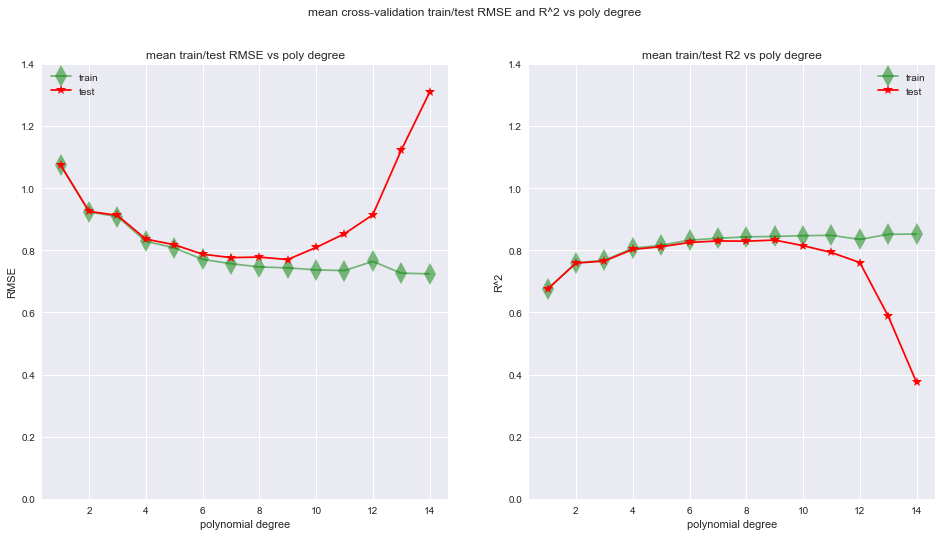

In [67]:
trainVsTestResults(gs_cv.cv_results_)

---

---

---

---

# Dragons be here.  This code can't necessarily be executed straight down.  See median_01 notebook for live version.

## Code from median_01

In [17]:
by_week = dfMod.groupby(['install_week'])
med_week = by_week.cost_per_watt.median()
mean_week = by_week.cost_per_watt.mean()

print(med_week.head())

install_week
1998-01-05/1998-01-11    10.734315
1998-01-26/1998-02-01    11.108701
1998-02-02/1998-02-08     8.667013
1998-03-30/1998-04-05    13.270286
1998-04-27/1998-05-03    14.654839
Freq: W-SUN, Name: cost_per_watt, dtype: float64


In [18]:
np.var(med_week), np.std(med_week)

(3.591240635756984, 1.8950568951239917)

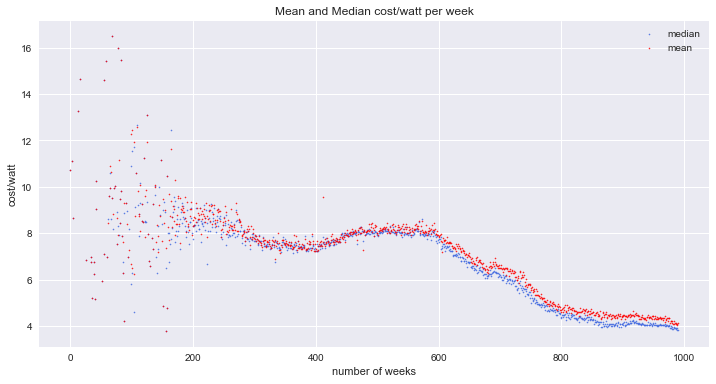

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
sTitle = 'Mean and Median cost/watt per week'

ax.set_title(sTitle)
ax.scatter(med_week.index - med_week.index[0], med_week, marker='.', 
            color='royalblue', s=6, alpha=0.8, label='median')
ax.scatter(mean_week.index - med_week.index[0], mean_week, marker='.', 
            color='red', s=6, alpha=0.8, label='mean')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of weeks')
ax.legend()

plt.show();

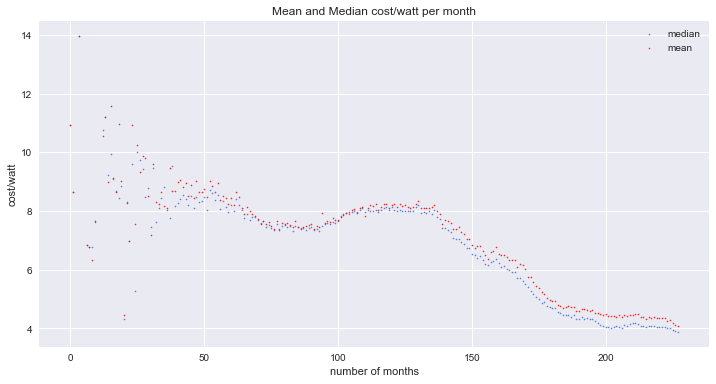

In [20]:
by_month = dfMod.groupby(['install_month'])
med_month = by_month.cost_per_watt.median()
mean_month = by_month.cost_per_watt.mean()

# print(med_month.head())

fig, ax = plt.subplots(figsize=(12, 6))
sTitle = 'Mean and Median cost/watt per month'

ax.set_title(sTitle)
ax.scatter(med_month.index - med_month.index[0], med_month, marker='.', 
            color='royalblue', s=6, alpha=0.8, label='median')
ax.scatter(mean_month.index - med_month.index[0], mean_month, marker='.', 
            color='red', s=6, alpha=0.8, label='mean')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of months')
ax.legend()

plt.show();

In [21]:
np.var(med_month), np.std(med_month)

(3.22558947367301, 1.7959926151499093)

#### Model median by months first; it will be the fastest

In [147]:
# Setup the pipeline steps
steps = [('scaler', StandardScaler()),
         ('poly', PolynomialFeatures()),
         ('LR', LinearRegression())]

# Create the pipeline: pipeline 
pipeline = Pipeline(steps)

In [23]:
pipeline.get_params()

{'memory': None,
 'steps': [('scaler',
   StandardScaler(copy=True, with_mean=True, with_std=True)),
  ('poly',
   PolynomialFeatures(degree=2, include_bias=True, interaction_only=False)),
  ('LR',
   LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False))],
 'scaler': StandardScaler(copy=True, with_mean=True, with_std=True),
 'poly': PolynomialFeatures(degree=2, include_bias=True, interaction_only=False),
 'LR': LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'poly__degree': 2,
 'poly__include_bias': True,
 'poly__interaction_only': False,
 'LR__copy_X': True,
 'LR__fit_intercept': True,
 'LR__n_jobs': 1,
 'LR__normalize': False}

In [24]:
num_months = (med_month.index - med_month.index[0]).values.astype(np.float); num_months[:5]

array([0., 1., 3., 6., 7.])

In [25]:
med_cpw = med_month.values; med_cpw[:5]

array([10.9215,  8.667 , 13.9626,  6.8589,  6.7682])

In [26]:
X = num_months.reshape(-1, 1)
y = med_cpw.reshape(-1, 1)

In [27]:
# we want to search and plot separately

# want to plot both R2 and RMSE
def RMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Create the hyperparameter grid, just poly degree
poly_space = np.arange(1, 21)
param_grid = {'poly__degree': poly_space}

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=21)

# build the scoring map
scoring = {'Rsquared': 'r2',
           'RMSE': make_scorer(RMSE, greater_is_better=False) }

# Create the GridSearchCV object: gs_cv
gs_cv = GridSearchCV(pipeline, param_grid, cv=3, scoring=scoring, 
                     return_train_score=True, refit='Rsquared')

# Fit to the training set
gs_cv.fit(X_train, y_train)

# Compute and print the metrics
theR2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("test R squared: {}".format(theR2))

# uncomment to see results ds
# gs_cv.cv_results_

Best parameters: {'poly__degree': 13}
test R squared: 0.7476147231880591


Best parameters: {'poly__degree': 13}
R squared with best parameters: 0.7476147231880591


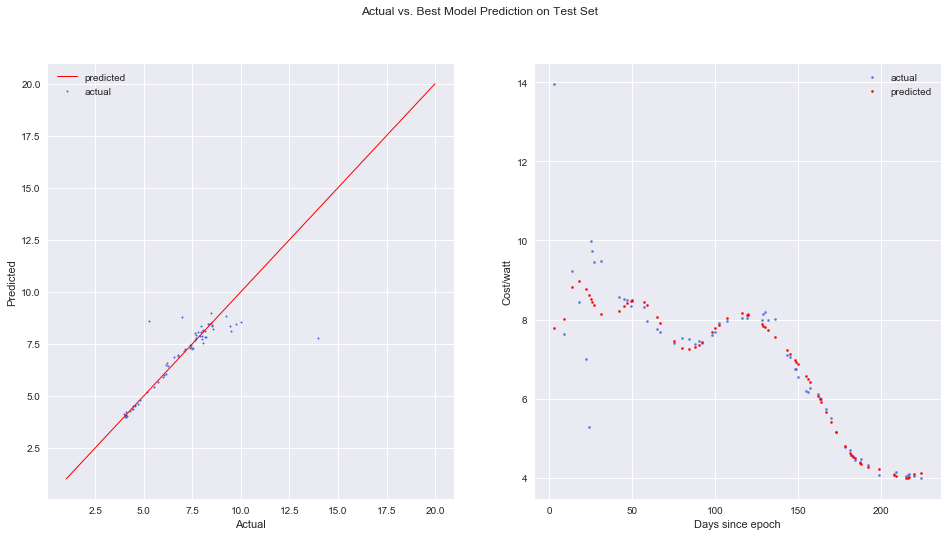

In [28]:
# Show R2
theR2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("R squared with best parameters: {}".format(theR2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Actual vs. Best Model Prediction on Test Set')

ax1.scatter(y_test, gs_cv.predict(X_test), marker='.', s=10, color='royalblue', alpha=1, label='actual')
ax1.plot(np.array([1,20]), np.array([1,20]), linewidth=1, color='red', label='predicted')
ax1.set_ylabel('Predicted')
ax1.set_xlabel('Actual')
ax1.legend()

ax2.scatter(X_test[:, 0], y_test, marker='.', color='royalblue', s=20, alpha=0.9, label='actual')
ax2.scatter(X_test[:, 0], gs_cv.predict(X_test), marker='.', color='red', s=20, alpha=1, label='predicted')
ax2.set_ylabel('Cost/watt')
ax2.set_xlabel('Days since epoch')
ax2.legend()

plt.show();

In [213]:
def trainVsTestResults(results, ylim=1.4): 
    ''' Plot test/train results for R^2 and RMSE'''    

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    sTitle = 'mean cross-validation train/test RMSE and R^2 vs poly degree'
    fig.suptitle(sTitle)
          
    mean_train_RMSE = results['mean_train_RMSE']
    mean_test_RMSE = results['mean_test_RMSE']
    n = len(mean_train_RMSE)
        
    ax1.plot(np.arange(1, n + 1), np.abs(mean_train_RMSE), marker='d', ms=15, alpha=0.5, color='green', label='train');
    ax1.plot(np.arange(1, n + 1), np.abs(mean_test_RMSE), marker='*', ms=10, alpha=1.0, color='red', label='test');
    ax1.set_ylabel('RMSE')
    ax1.set_xlabel('polynomial degree')
    ax1.set_title('mean train/test RMSE vs poly degree')
    ax1.set_ylim(0, ylim)
    ax1.legend()
    
    mean_train_R2 = results['mean_train_Rsquared']
    mean_test_R2 = results['mean_test_Rsquared']
    n = len(mean_train_R2)
    
    fig.suptitle(sTitle.format(gs_cv.best_params_))

    ax2.plot(np.arange(1, n + 1), np.abs(mean_train_R2), marker='d', ms=15, alpha=0.5, color='green', label='train');
    ax2.plot(np.arange(1, n + 1), np.abs(mean_test_R2), marker='*', ms=10, color='red', label='test');
    ax2.set_ylabel('R^2')
    ax2.set_xlabel('polynomial degree')
    ax2.set_title('mean train/test R2 vs poly degree')
    ax2.set_ylim(0, ylim)
    ax2.legend()
          
    r2 = gs_cv.score(X_test, y_test)
    print("Best parameters: {}".format(gs_cv.best_params_))
    print("Best parameters test R squared: {}".format(r2))

Best parameters: {'poly__degree': 13}
Best parameters test R squared: 0.7476147231880591


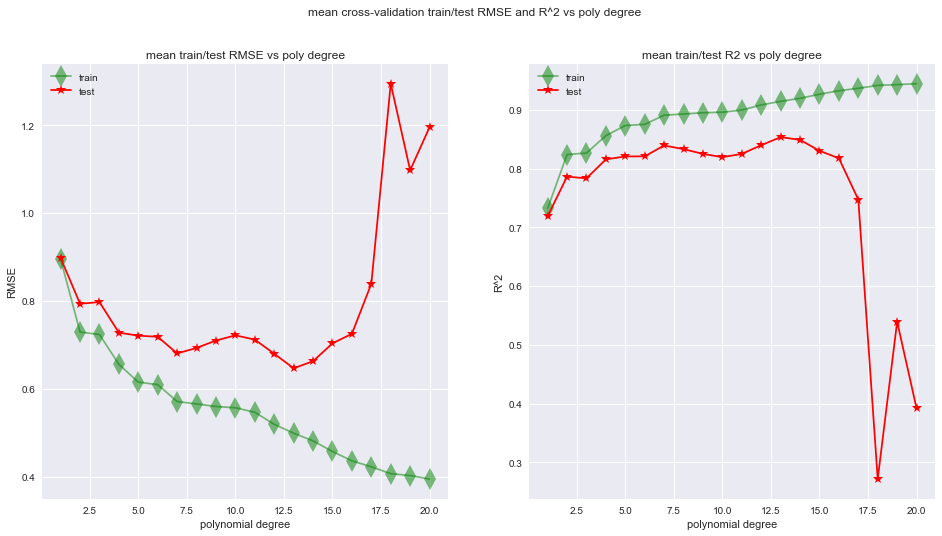

In [30]:
trainVsTestResults(gs_cv.cv_results_)

### Model median by week

In [31]:
num_weeks = (med_week.index - med_week.index[0]).values.astype(np.float); num_weeks[:5]

array([ 0.,  3.,  4., 12., 16.])

In [32]:
med_week[:5]

install_week
1998-01-05/1998-01-11    10.734315
1998-01-26/1998-02-01    11.108701
1998-02-02/1998-02-08     8.667013
1998-03-30/1998-04-05    13.270286
1998-04-27/1998-05-03    14.654839
Freq: W-SUN, Name: cost_per_watt, dtype: float64

In [33]:
X = num_weeks.reshape(-1,1)
y = med_week.values.reshape(-1,1)

In [34]:
# we want to search and plot separately

# want to plot both R2 and RMSE
def RMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Create the hyperparameter grid, just poly degree
poly_space = np.arange(1, 21)
param_grid = {'poly__degree': poly_space}

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=21)

# build the scoring map
scoring = {'Rsquared': 'r2',
           'RMSE': make_scorer(RMSE, greater_is_better=False) }

# Create the GridSearchCV object: gs_cv
gs_cv = GridSearchCV(pipeline, param_grid, cv=3, scoring=scoring, 
                     return_train_score=True, refit='Rsquared')

# Fit to the training set
gs_cv.fit(X_train, y_train)

# Compute and print the metrics
theR2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("test R squared: {}".format(theR2))

# uncomment to see results ds
# gs_cv.cv_results_

Best parameters: {'poly__degree': 8}
test R squared: 0.849081575150797


Best parameters: {'poly__degree': 8}
Best R squared: 0.849081575150797


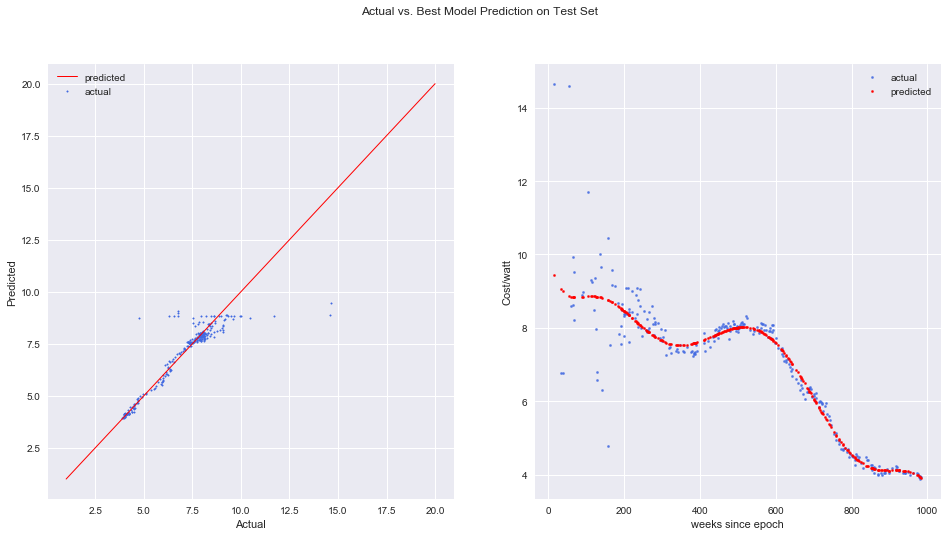

In [35]:
# Show R2
theR2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("Best R squared: {}".format(theR2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Actual vs. Best Model Prediction on Test Set')

ax1.scatter(y_test, gs_cv.predict(X_test), marker='.', s=10, color='royalblue', alpha=1, label='actual')
ax1.plot(np.array([1,20]), np.array([1,20]), linewidth=1, color='red', label='predicted')
ax1.set_ylabel('Predicted')
ax1.set_xlabel('Actual')
ax1.legend()

ax2.scatter(X_test[:, 0], y_test, marker='.', color='royalblue', s=20, alpha=0.9, label='actual')
ax2.scatter(X_test[:, 0], gs_cv.predict(X_test), marker='.', color='red', s=20, alpha=1, label='predicted')
ax2.set_ylabel('Cost/watt')
ax2.set_xlabel('weeks since epoch')
ax2.legend()

plt.show();

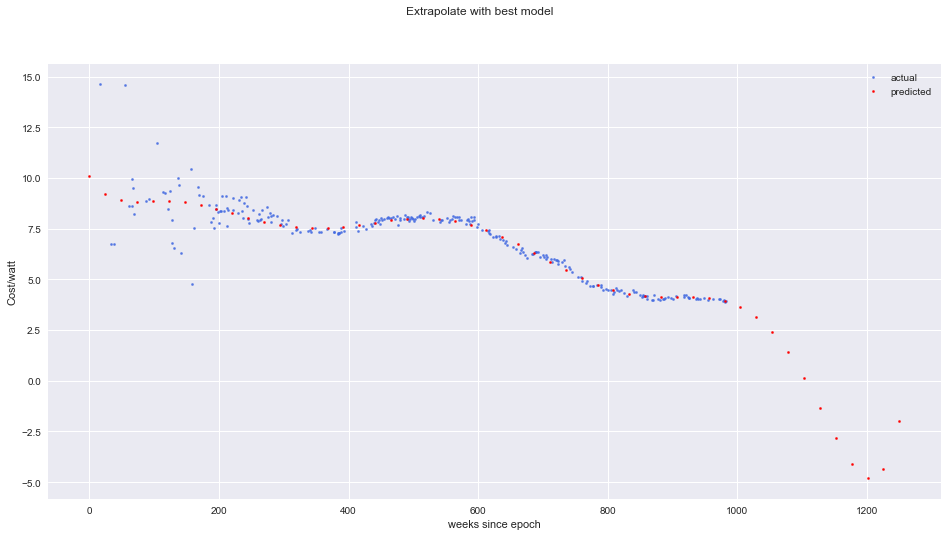

In [36]:
fig, ax = plt.subplots(figsize=(16, 8))
fig.suptitle('Extrapolate with best model')

X_future = np.linspace(0.0, 1250.0, 52).reshape(-1,1)
ax.scatter(X_test[:,0], y_test, marker='.', color='royalblue', s=20, alpha=0.9, label='actual')
ax.scatter(X_future, gs_cv.predict(X_future), marker='.', color='red', s=20, alpha=1, label='predicted')
ax.set_ylabel('Cost/watt')
ax.set_xlabel('weeks since epoch')
ax.legend();



Best parameters: {'poly__degree': 8}
Best parameters test R squared: 0.849081575150797


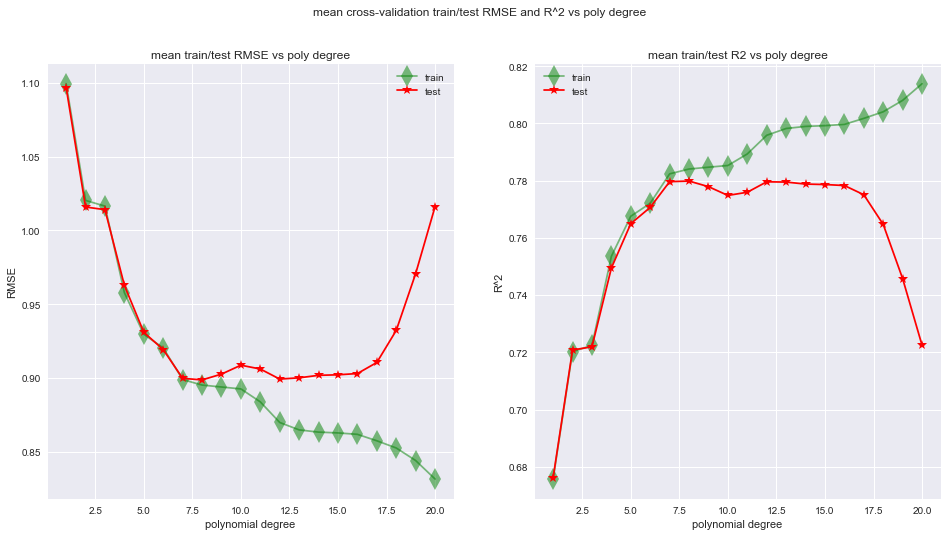

In [37]:
trainVsTestResults(gs_cv.cv_results_)

### Now daily medians

In [38]:
X = (med_date.index - med_date.index[0]).days.values.astype(np.float).reshape(-1, 1)
y = med_date.values.reshape(-1, 1)

In [39]:
# we want to search and plot separately

# want to plot both R2 and RMSE
def RMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Create the hyperparameter grid, just poly degree
poly_space = np.arange(1, 21)
param_grid = {'poly__degree': poly_space}

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=21)

# build the scoring map
scoring = {'Rsquared': 'r2',
           'RMSE': make_scorer(RMSE, greater_is_better=False) }

# Create the GridSearchCV object: gs_cv
gs_cv = GridSearchCV(pipeline, param_grid, cv=3, scoring=scoring, 
                     return_train_score=True, refit='Rsquared')

# Fit to the training set
gs_cv.fit(X_train, y_train)

# Compute and print the metrics
theR2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("test R squared: {}".format(theR2))

# uncomment to see results ds
# gs_cv.cv_results_

Best parameters: {'poly__degree': 8}
test R squared: 0.7526628460347233


Best parameters: {'poly__degree': 8}
Best R squared: 0.7526628460347233


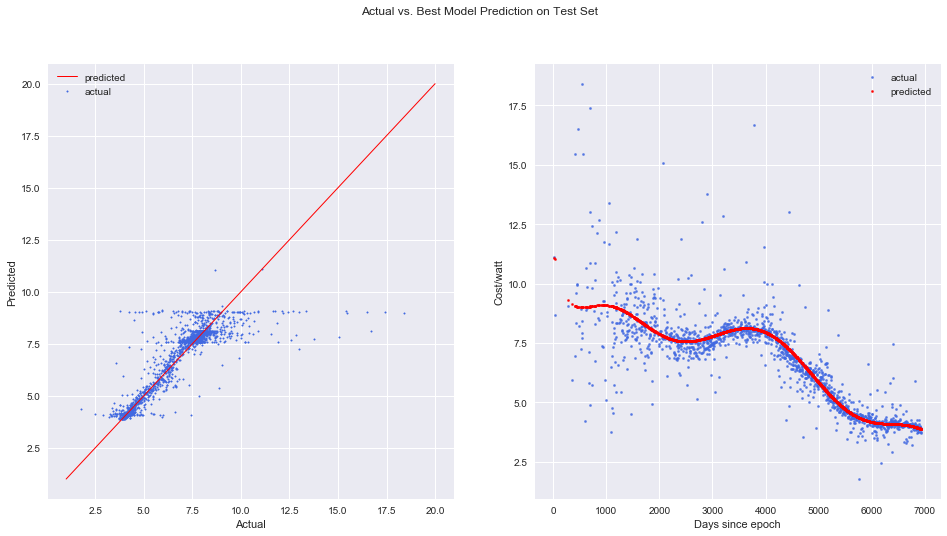

In [40]:
# Show R2
theR2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("Best R squared: {}".format(theR2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Actual vs. Best Model Prediction on Test Set')

ax1.scatter(y_test, gs_cv.predict(X_test), marker='.', s=10, color='royalblue', alpha=1, label='actual')
ax1.plot(np.array([1,20]), np.array([1,20]), linewidth=1, color='red', label='predicted')
ax1.set_ylabel('Predicted')
ax1.set_xlabel('Actual')
ax1.legend()

ax2.scatter(X_test[:, 0], y_test, marker='.', color='royalblue', s=20, alpha=0.9, label='actual')
ax2.scatter(X_test[:, 0], gs_cv.predict(X_test), marker='.', color='red', s=20, alpha=1, label='predicted')
ax2.set_ylabel('Cost/watt')
ax2.set_xlabel('Days since epoch')
ax2.legend()

plt.show();

Best parameters: {'poly__degree': 8}
Best parameters test R squared: 0.7526628460347233


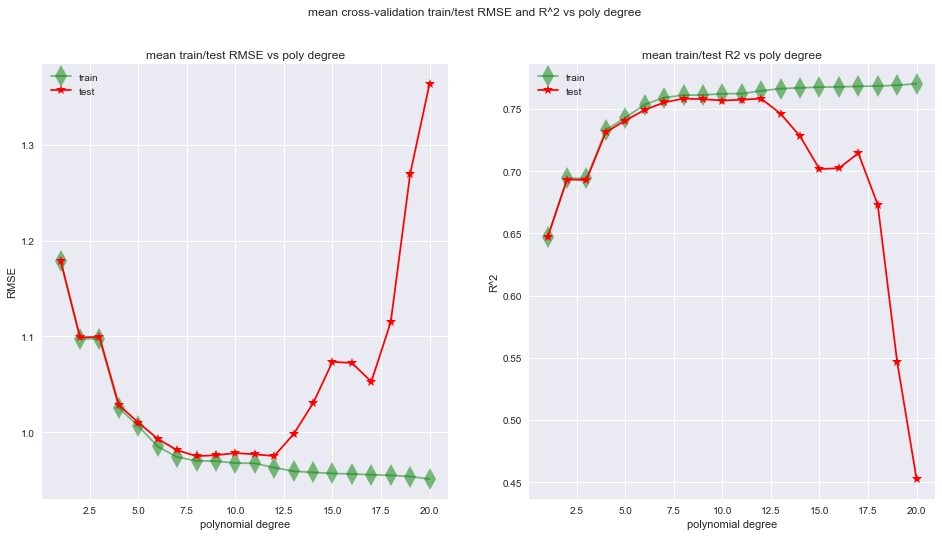

In [41]:
trainVsTestResults(gs_cv.cv_results_)

---

### Weights seem to make no difference, though there's no complaint.

### try this again but with weights
```
weight(sample) = sample.size/total.size
```

Have to be careful here.  The weights need to be shuffled along with the data.  Does GridSearch_cv manage that??  It must because it manages to do X and y together...

In [42]:
# by_date = dfMod.groupby(['install_date'])
# med_date = by_date.cost_per_watt.median()
# mean_date = by_date.cost_per_watt.mean()

day_weights = by_date.size()/len(dfMod)


In [43]:
# we want to search and plot separately

# want to plot both R2 and RMSE
def RMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Create the hyperparameter grid, just poly degree
poly_space = np.arange(1, 21)
param_grid = {'poly__degree': poly_space}

# Create train and test sets with weights
X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(X, y, 
                                                                                 day_weights.values.reshape(-1, 1), 
                                                                                 test_size=0.30, random_state=21)

# build the scoring mapping
scoring = {'Rsquared': 'r2',
           'RMSE': make_scorer(RMSE, greater_is_better=False) }

# Create the GridSearchCV object: gs_cv
gs_cv = GridSearchCV(pipeline, param_grid, cv=3, scoring=scoring, 
                     return_train_score=True, refit='Rsquared')

# Fit to the training set
gs_cv.fit(X_train, y_train, weights_train)

# Compute and print the metrics
theR2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("test R squared: {}".format(theR2))

Best parameters: {'poly__degree': 8}
test R squared: 0.7526628460347233


Best parameters: {'poly__degree': 8}
Best R squared: 0.7526628460347233


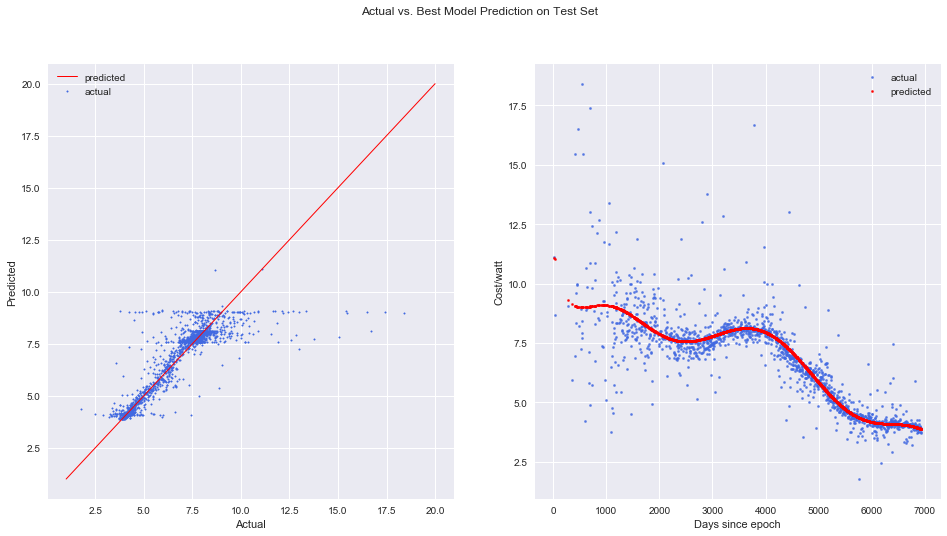

In [44]:
# Show R2
theR2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("Best R squared: {}".format(theR2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Actual vs. Best Model Prediction on Test Set')

ax1.scatter(y_test, gs_cv.predict(X_test), marker='.', s=10, color='royalblue', alpha=1, label='actual')
ax1.plot(np.array([1,20]), np.array([1,20]), linewidth=1, color='red', label='predicted')
ax1.set_ylabel('Predicted')
ax1.set_xlabel('Actual')
ax1.legend()

ax2.scatter(X_test[:, 0], y_test, marker='.', color='royalblue', s=20, alpha=0.9, label='actual')
ax2.scatter(X_test[:, 0], gs_cv.predict(X_test), marker='.', color='red', s=20, alpha=1, label='predicted')
ax2.set_ylabel('Cost/watt')
ax2.set_xlabel('Days since epoch')
ax2.legend()

plt.show();

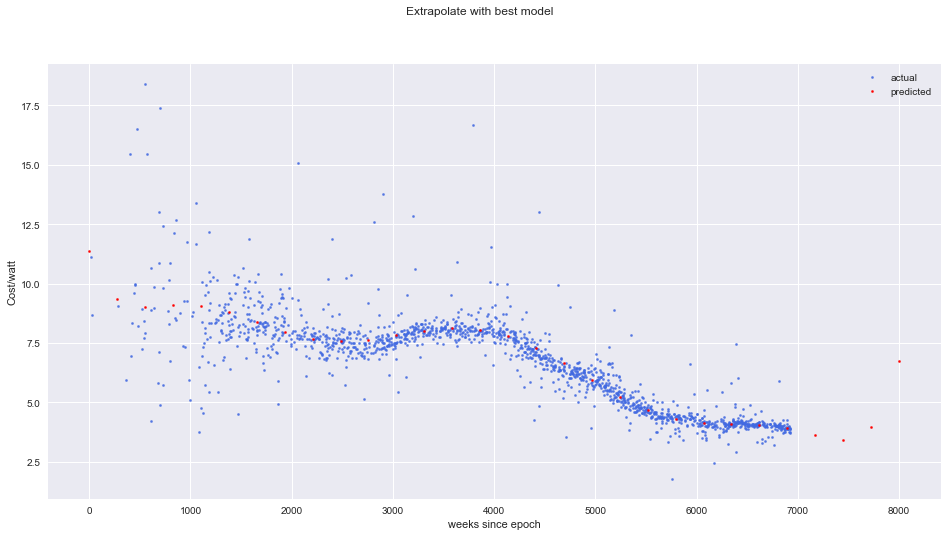

In [45]:
fig, ax = plt.subplots(figsize=(16, 8))
fig.suptitle('Extrapolate with best model')

X_future = np.linspace(0.0, 8000, 30).reshape(-1,1)
ax.scatter(X_test[:,0], y_test, marker='.', color='royalblue', s=20, alpha=0.9, label='actual')
ax.scatter(X_future, gs_cv.predict(X_future), marker='.', color='red', s=20, alpha=1, label='predicted')
ax.set_ylabel('Cost/watt')
ax.set_xlabel('weeks since epoch')
ax.legend();

